In [7]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [8]:
env = gym.make('FrozenLake-v1', map_name = '4x4', is_slippery = False, render_mode = 'rgb_array')
q_table = np.zeros(shape=(env.observation_space.n, env.action_space.n))
rewards_per_episode = []
epsilon_decay_graph = []

In [9]:
learning_rate = 0.9 # alpha
discount_factor = 0.9 # gamma
epsilon = 0.9 # random actions
epsilon_decay_rate = 0.0001
n_episodes = 3000

In [10]:
for i in range(n_episodes):
    state = env.reset()[0] # Generates a new starting state

    terminated, truncated = False, False

    accumulated_reward = 0


    # Choose initial action using epsilon-greedy policy
    if (np.random.random() < epsilon): # Exploaratory action 90% of the time
            action = env.action_space.sample()
    else:
        action = np.argmax(q_table[state])

    while (not terminated and not truncated):
        
        new_state, reward, terminated, truncated, info = env.step(action)

        # Choose the NEXT action using the exact same epsilon-greedy policy
        if (np.random.random() < epsilon): # Exploaratory action 90% of the time
            new_action = env.action_space.sample()
        else:
            new_action = np.argmax(q_table[new_state])
        
        # Q - Learning
        # if terminated == True:
        #     q_table[state][action] += learning_rate * ((reward + discount_factor * 0) - q_table[state][action])
        # else: 
        #     q_table[state][action] += learning_rate * ((reward + discount_factor * np.max(q_table[new_state])) - q_table[state][action])

        # SARSA
        if terminated == True:
            q_table[state][action] += learning_rate * ((reward + discount_factor * 0) - q_table[state][action])
        else: 
            q_table[state][action] += learning_rate * (reward + (discount_factor * q_table[new_state][new_action]) - q_table[state][action])



        accumulated_reward += reward
        action = new_action
        state = new_state
    rewards_per_episode.append(accumulated_reward)
    epsilon = max(epsilon - epsilon_decay_rate, 0.1)
    epsilon_decay_graph.append(epsilon)
env.close()

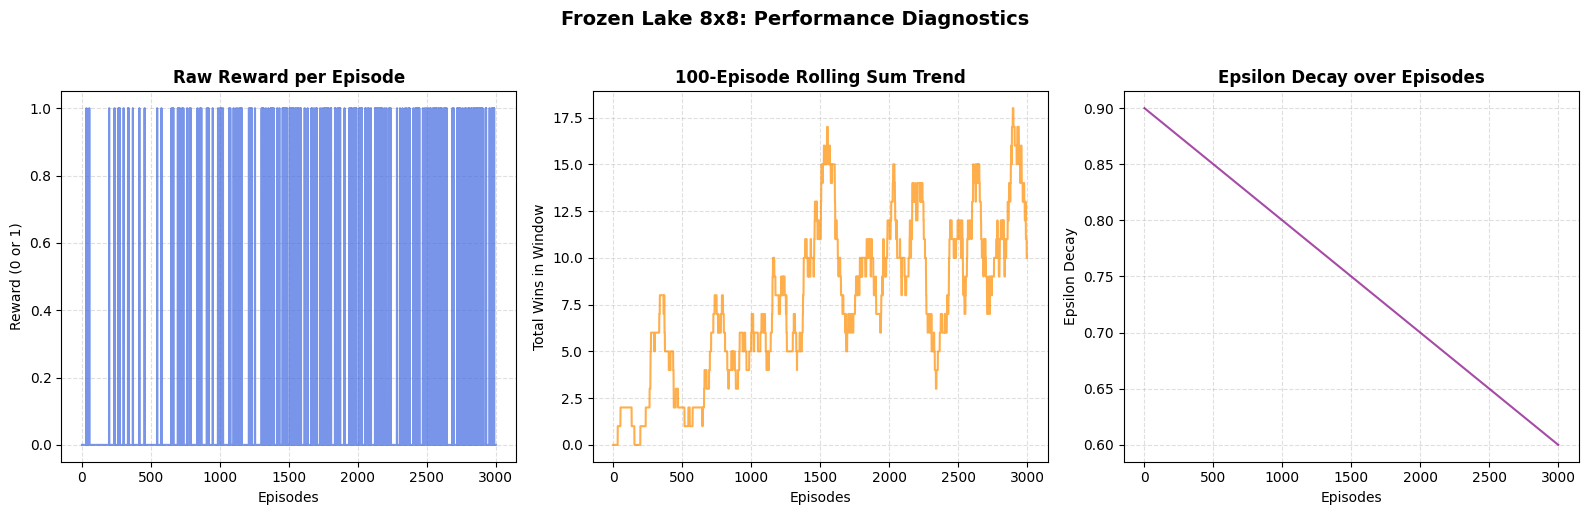

[[1.91684598e-03 1.03053392e-03 1.54971072e-04 8.34866910e-04]
 [1.52808472e-03 0.00000000e+00 1.95316300e-03 2.37299330e-03]
 [1.23526804e-03 1.66619301e-04 9.56210429e-03 1.04993856e-02]
 [1.35353420e-02 0.00000000e+00 9.03899336e-03 6.40763368e-04]
 [8.84221033e-03 3.96357182e-03 0.00000000e+00 8.95325061e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.32927337e-02 0.00000000e+00 1.57252924e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.43069469e-03 0.00000000e+00 1.82496620e-03 1.17868561e-04]
 [4.92667360e-03 1.31584422e-01 1.21976634e-02 0.00000000e+00]
 [5.39821483e-01 8.13107971e-01 0.00000000e+00 2.08623353e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 7.29749400e-01 8.25747546e-01 1.02642619e-03]
 [1.35985467e-01 8.99227783e-01 1.00000000e+00 2.43051130e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

In [18]:
sum_rewards = np.zeros(n_episodes)
for t in range(n_episodes):
    sum_rewards[t] = np.sum(rewards_per_episode[max(0,t-100):(t+1)]) # 100-episode rolling window sum of rewards

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Graph 1: Raw Reward per Episode
ax1.plot(rewards_per_episode, color='royalblue', alpha=0.7)
ax1.set_title('Raw Reward per Episode', fontsize=12, fontweight='bold')
ax1.set_xlabel('Episodes')
ax1.set_ylabel('Reward (0 or 1)')
ax1.grid(True, linestyle='--', alpha=0.4) # of the grid in the background

# Graph 2: 100-Episode Rolling Sum
ax2.plot(sum_rewards, color='darkorange', alpha = 0.7)
ax2.set_title('100-Episode Rolling Sum Trend', fontsize=12, fontweight='bold')
ax2.set_xlabel('Episodes')
ax2.set_ylabel('Total Wins in Window')
ax2.grid(True, linestyle='--', alpha=0.4)

# Graph 3:
ax3.plot(range(n_episodes), epsilon_decay_graph, color='purple', alpha = 0.7)
ax3.set_title('Epsilon Decay over Episodes', fontsize=12, fontweight='bold')
ax3.set_xlabel('Episodes')
ax3.set_ylabel('Epsilon Decay')
ax3.grid(True, linestyle='--', alpha=0.4)

# 3. Save and clean up the display layout
plt.suptitle('Frozen Lake 8x8: Performance Diagnostics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout() 
plt.savefig('frozen_lake8x8_separated.png', dpi=300, bbox_inches='tight') 
plt.show()


f = open('frozen_lake8x8.pk1', 'wb')
pickle.dump(q_table,f) # Saving the Q_Table
f.close()


# view the q_table normally
with open('frozen_lake8x8.pk1', 'rb') as f:
    loaded_q_table = pickle.load(f)
print(loaded_q_table)